## Imports

In [6]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as imageio
from tqdm import tqdm
from sklearn.metrics import jaccard_score
from transformers import SegformerForSemanticSegmentation

## Settings

In [7]:
# Paths
model_path = "../models/best_model.pth"
test_images_dir = "../data/processed/test/images/"
test_masks_dir = "../data/processed/test/masks/"

# Hyperparameters
num_classes = 3
image_size = 256

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Load Model

In [8]:
# Load SegFormer model architecture
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
# Load your fine-tuned weights
model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([3]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([3, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

## List Test Images

In [9]:
test_image_files = sorted(os.listdir(test_images_dir))
test_mask_files = sorted(os.listdir(test_masks_dir))

print(f"Found {len(test_image_files)} test images")

Found 2440 test images


## Prediction and mIoU Calculation

In [10]:
def compute_mean_iou(preds, labels, num_classes):
    preds = preds.flatten()
    labels = labels.flatten()
    return jaccard_score(labels, preds, average="macro", labels=list(range(num_classes)))

In [11]:
all_preds = []
all_labels = []
ious = []

for img_file, mask_file in tqdm(zip(test_image_files, test_mask_files), total=len(test_image_files), desc="Evaluating on Test Set"):
    # Load image and mask
    img_path = os.path.join(test_images_dir, img_file)
    mask_path = os.path.join(test_masks_dir, mask_file)

    image = imageio.imread(img_path)
    mask = imageio.imread(mask_path)

    # Expand to 3 channels if grayscale
    if len(image.shape) == 2:
        image = np.stack([image, image, image], axis=0)

    image = torch.from_numpy(image).unsqueeze(0).float() / 255.0  # (1, 3, H, W)
    mask = torch.from_numpy(mask).long()  # (H, W)

    image = image.to(device)

    # Predict
    with torch.no_grad():
        outputs = model(pixel_values=image).logits  # (1, C, h, w)
        outputs = torch.nn.functional.interpolate(outputs, size=(image_size, image_size), mode="bilinear", align_corners=False)
        preds = torch.argmax(outputs, dim=1).squeeze(0).cpu()  # (H, W)

    # Flatten and collect
    all_preds.append(preds.numpy().flatten())
    all_labels.append(mask.numpy().flatten())

    # Per-image mIoU
    iou = compute_mean_iou(preds.numpy(), mask.numpy(), num_classes)
    ious.append(iou)

# Stack all predictions
all_preds_flat = np.concatenate(all_preds)
all_labels_flat = np.concatenate(all_labels)

# Final metrics
mean_test_iou = np.mean(ious)
print(f"\nMean IoU on Test Set (averaged across images): {mean_test_iou:.4f}")

print("\nPer-Class IoU on Test Set:")
class_names = ["Background", "Liver", "Tumor"]
for i in range(num_classes):
    binary_iou = jaccard_score(all_labels_flat == i, all_preds_flat == i)
    print(f"{class_names[i]} IoU: {binary_iou:.4f}")

Evaluating on Test Set:   0%|          | 0/2440 [00:00<?, ?it/s]/root/.local/share/virtualenvs/app-4PlAip0Q/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in labels with no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.local/share/virtualenvs/app-4PlAip0Q/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in labels with no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.local/share/virtualenvs/app-4PlAip0Q/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 in labels with no true or predicted sample


Mean IoU on Test Set (averaged across images): 0.6208

Per-Class IoU on Test Set:
Background IoU: 0.9900
Liver IoU: 0.8658
Tumor IoU: 0.2386


## Plotting Random Predictions

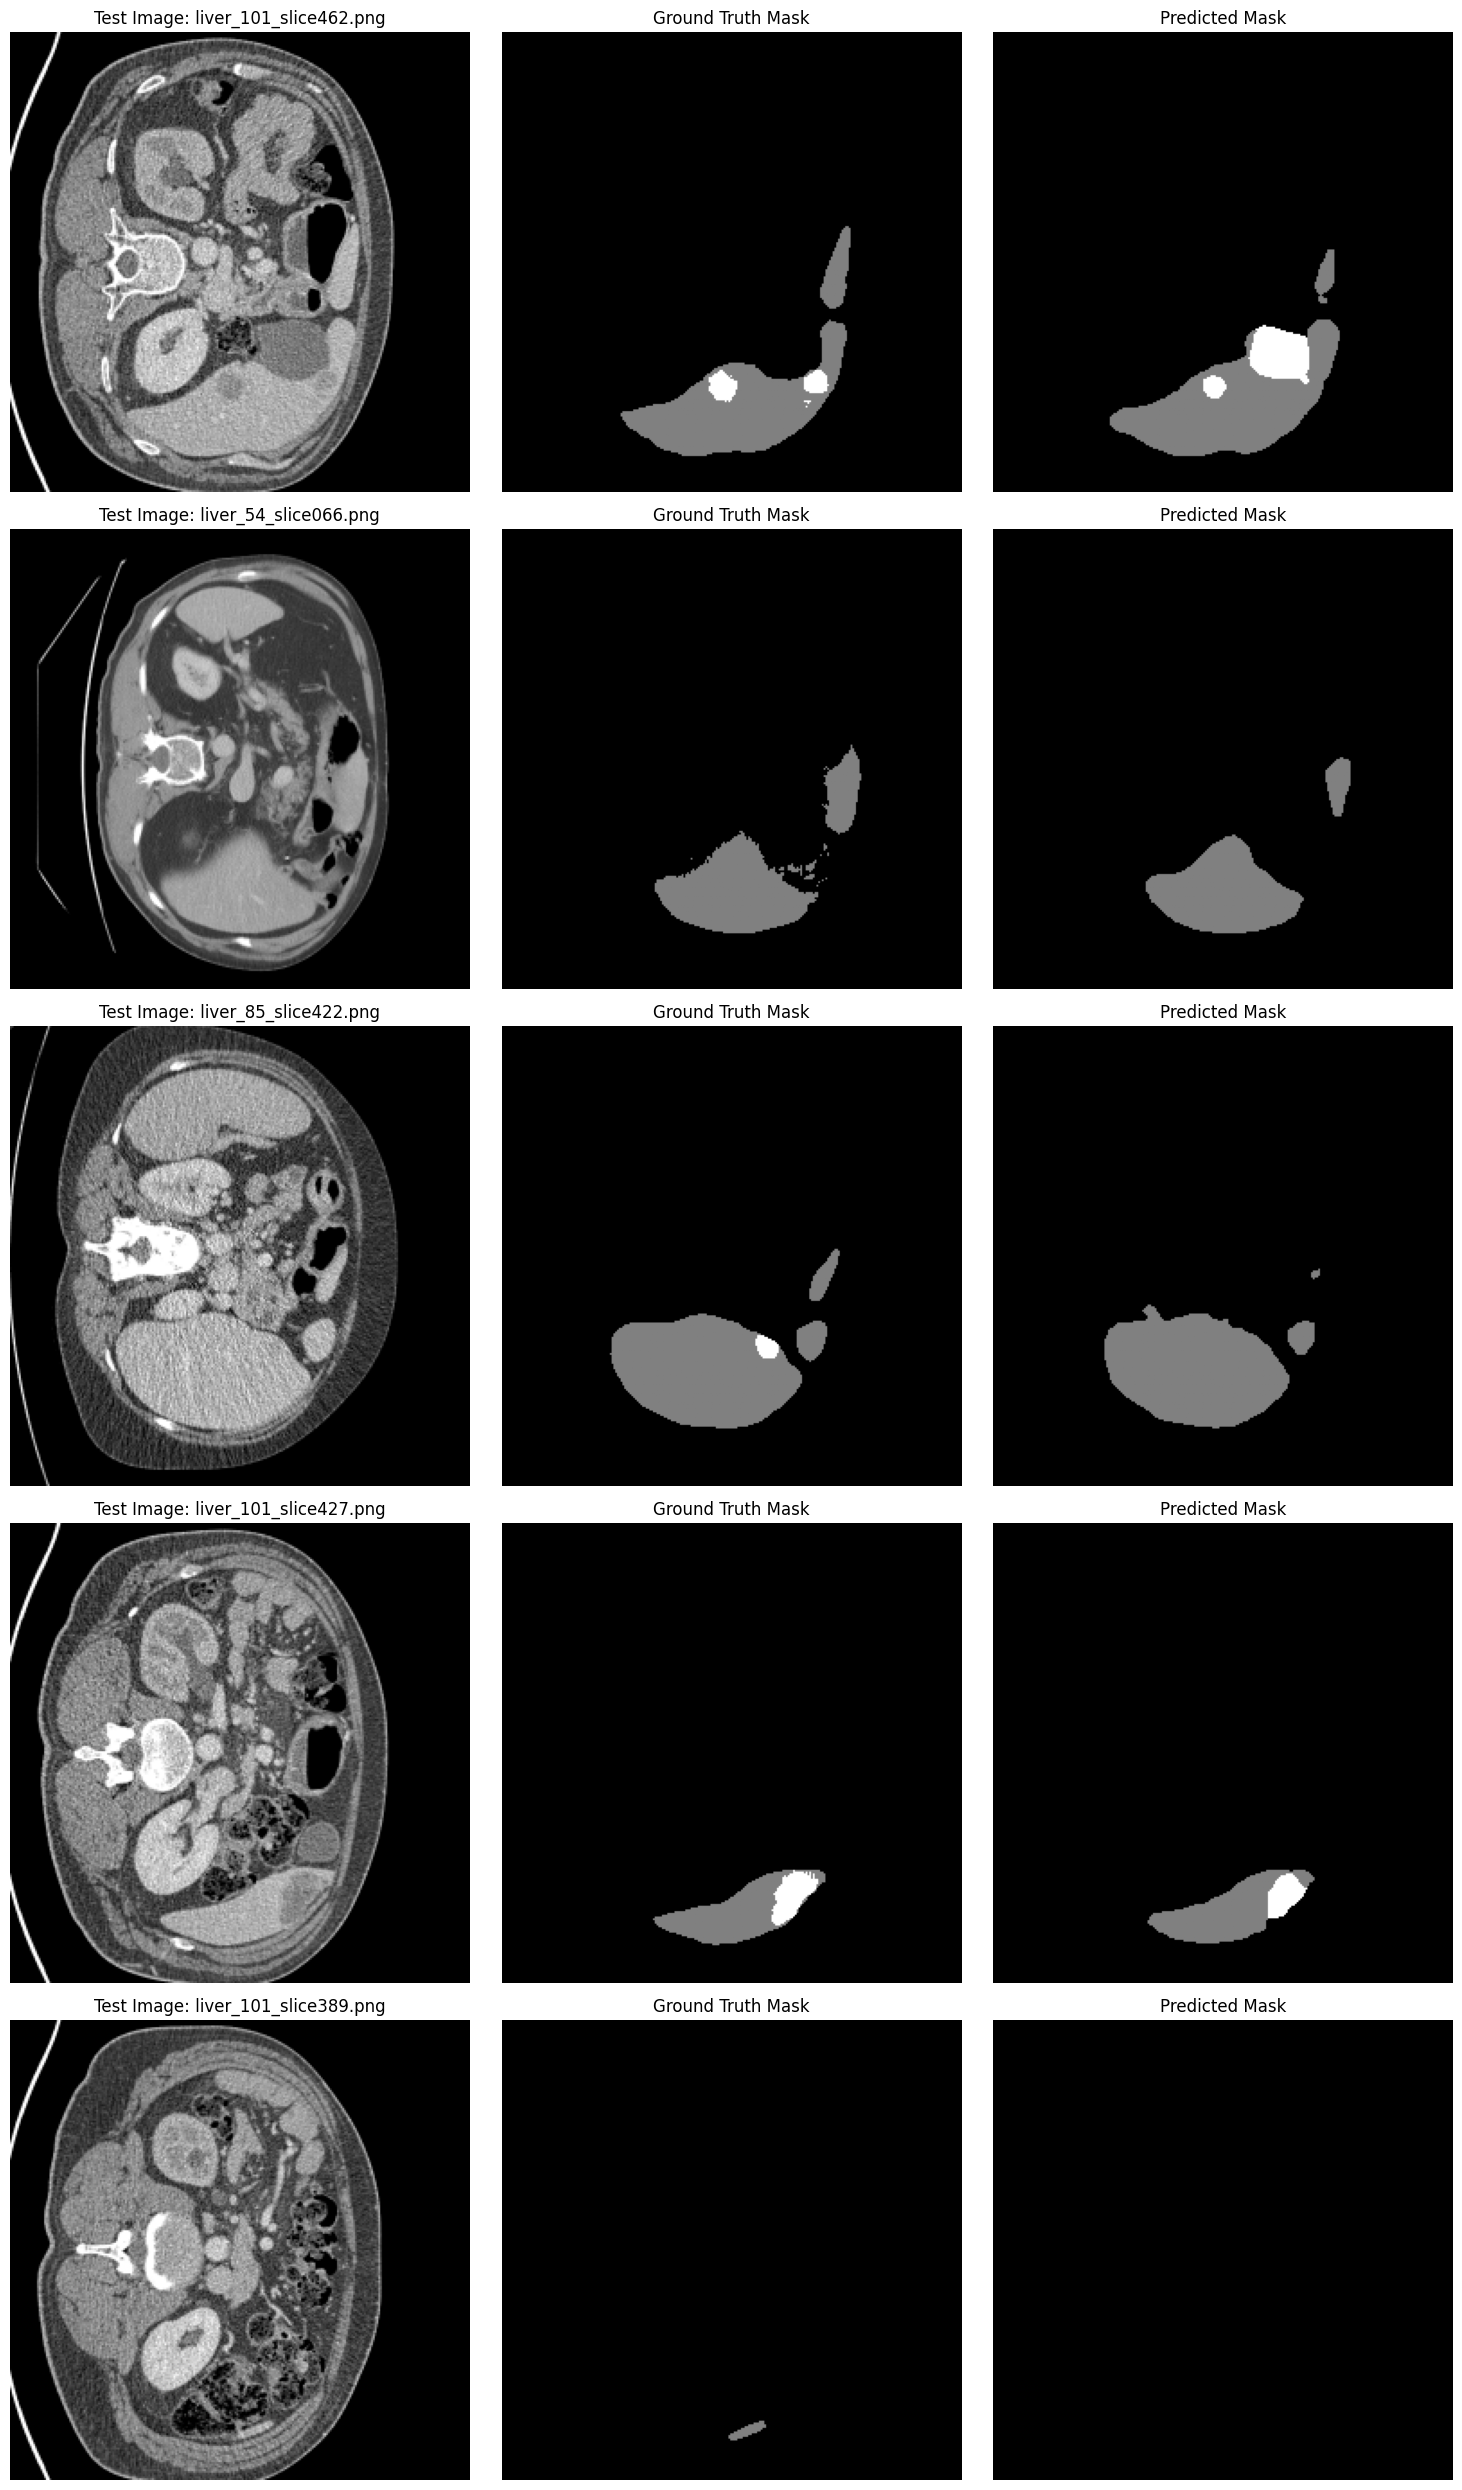

In [12]:
def plot_sample_predictions(n=5):
    selected_indices = np.random.choice(len(test_image_files), size=n, replace=False)

    fig, axs = plt.subplots(n, 3, figsize=(15, 5 * n))

    for i, idx in enumerate(selected_indices):
        img_path = os.path.join(test_images_dir, test_image_files[idx])
        mask_path = os.path.join(test_masks_dir, test_mask_files[idx])

        image = imageio.imread(img_path)
        mask = imageio.imread(mask_path)

        if len(image.shape) == 2:
            image_input = np.stack([image, image, image], axis=0)
        else:
            image_input = image.transpose(2, 0, 1)

        image_tensor = torch.from_numpy(image_input).unsqueeze(0).float() / 255.0
        image_tensor = image_tensor.to(device)

        with torch.no_grad():
            outputs = model(pixel_values=image_tensor).logits
            outputs = torch.nn.functional.interpolate(outputs, size=(image_size, image_size), mode="bilinear", align_corners=False)
            preds = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()

        # Plot input image
        axs[i, 0].imshow(image, cmap="gray")
        axs[i, 0].set_title(f"Test Image: {test_image_files[idx]}")
        axs[i, 0].axis('off')

        # Ground Truth Mask
        axs[i, 1].imshow(mask, cmap="gray", vmin=0, vmax=2)
        axs[i, 1].set_title("Ground Truth Mask")
        axs[i, 1].axis('off')

        # Predicted Mask
        axs[i, 2].imshow(preds, cmap="gray", vmin=0, vmax=2)
        axs[i, 2].set_title("Predicted Mask")
        axs[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

plot_sample_predictions(n=5)
